In [1]:
import pandas as pd
import glob
import string
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from nltk.corpus import wordnet
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, pipeline
from transformers_interpret import SequenceClassificationExplainer
from datasets import Dataset,load_dataset
from sklearn.preprocessing import LabelEncoder
import torch
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from torch import nn
from captum.attr import LayerIntegratedGradients

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Combining separte files into one

In [ ]:
folder_path = "CSV files/*.csv"
all_files = glob.glob(folder_path)
df_list = [pd.read_csv(filename) for filename in all_files]
df = pd.concat(df_list, ignore_index=True)

In [ ]:
df.head()

,,Time,Time.1,Place,Place.1,Place.2,Place.3,Place.4,Place.5,Place.6,...,Events.4,Events.5,Assessments,Assessments.1,Report 1,Report 1.1,Report 2,Report 2.1,Report 1.2,Unnamed: 125
0,ACN,Date,Local Time Of Day,Locale Reference,State Reference,Relative Position.Angle.Radial,Relative Position.Distance.Nautical Miles,Altitude.AGL.Single Value,Altitude.MSL.Single Value,Latitude / Longitude (UAS),...,When Detected,Result,Contributing Factors / Situations,Primary Problem,Narrative,Callback,Narrative,Callback,Synopsis,NaN
1,1714400,202001,0001-0600,ORD.Airport,IL,NaN,NaN,NaN,15000,NaN,...,In-flight,Air Traffic Control Issued New Clearance; Air ...,Aircraft; Company Policy,Company Policy,To be clear I did not have a lot going on and ...,NaN,NaN,NaN,A TRACON Departure Controller reported two air...,NaN
2,1714553,202001,1801-2400,ZHU.ARTCC,TX,NaN,NaN,NaN,14000,NaN,...,In-flight,Flight Crew Became Reoriented; General Physica...,Human Factors; Environment - Non Weather Related,Environment - Non Weather Related,While descending into PIB out of 14;000 ft. MS...,NaN,NaN,NaN,CRJ Captain reported that a laser shone repeat...,NaN
3,1714675,202001,1801-2400,ZZZ.ARTCC,US,NaN,NaN,NaN,9000,NaN,...,In-flight,Flight Crew Returned To Departure Airport; Fli...,Aircraft; Weather; Procedure,Weather,I was boarding the aircraft when a my destinat...,NaN,NaN,NaN,Pilot reported weather and a closed destinatio...,NaN
4,1714708,202001,0601-1200,ZZZ.Airport,US,NaN,NaN,0,NaN,NaN,...,In-flight,General None Reported / Taken,Procedure; Logbook Entry; Human Factors,Ambiguous,I had a ferry flight that went out of service ...,NaN,We departed ZZZ ferrying an un-airworthy aircr...,NaN,Air carrier Dispatcher and flight crew reporte...,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31141 entries, 0 to 31140
Columns: 126 entries,   to Unnamed: 125
dtypes: float64(1), object(125)
memory usage: 29.9+ MB


In [ ]:
df_1 = df.copy()

In [ ]:
df_1 = df_1[['Assessments.1','Report 1']]

In [ ]:
df_1.head()

,Assessments.1,Report 1
0,Primary Problem,Narrative
1,Company Policy,To be clear I did not have a lot going on and ...
2,Environment - Non Weather Related,While descending into PIB out of 14;000 ft. MS...
3,Weather,I was boarding the aircraft when a my destinat...
4,Ambiguous,I had a ferry flight that went out of service ...


In [ ]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31141 entries, 0 to 31140
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Assessments.1  31064 non-null  object
 1   Report 1       31138 non-null  object
dtypes: object(2)
memory usage: 486.7+ KB


Checking for missing values

In [ ]:
df_1.isnull().sum()/len(df_1) * 100

,0
Assessments.1,0.247262
Report 1,0.009634


Dropping Missing Values

In [ ]:
df_1.dropna(inplace = True)

In [ ]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31064 entries, 0 to 31140
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Assessments.1  31064 non-null  object
 1   Report 1       31064 non-null  object
dtypes: object(2)
memory usage: 728.1+ KB


In [ ]:
df_1.isnull().sum()/len(df_1) * 100

,0
Assessments.1,0.0
Report 1,0.0


Changing column name to first row

In [ ]:
df_1.columns = df_1.iloc[0]
df_1 = df_1.drop(df.index[0])
df_1 = df_1.reset_index(drop=True)

In [ ]:
df_1.head()

,Primary Problem,Narrative
0,Company Policy,To be clear I did not have a lot going on and ...
1,Environment - Non Weather Related,While descending into PIB out of 14;000 ft. MS...
2,Weather,I was boarding the aircraft when a my destinat...
3,Ambiguous,I had a ferry flight that went out of service ...
4,Aircraft,We were flying at 2500 ft. I started losing el...


In [ ]:
df_1['Primary Problem'].value_counts()

,count
Primary Problem,
Human Factors,10823
Aircraft,9802
Procedure,2913
Ambiguous,2490
Weather,1059
Environment - Non Weather Related,930
Airport,786
Chart Or Publication,447
Airspace Structure,411


In [ ]:
df_2 = df_1.copy()

[]

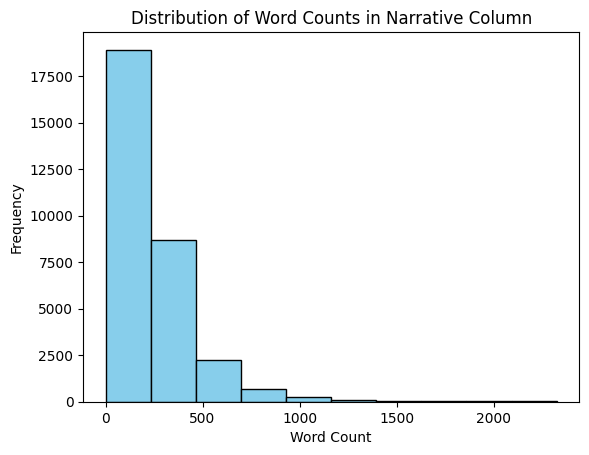

In [ ]:
df_2['word_count'] = df_2['Narrative'].str.split().str.len()

fig, ax = plt.subplots()
ax.hist(df_2['word_count'], bins=10, edgecolor='black', color='skyblue')
ax.set_title('Distribution of Word Counts in Narrative Column')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')

plt.plot()

Making narrative lowercase

In [ ]:
df_1['Narrative'] = df_1['Narrative'].str.lower()
df_1['Narrative'][0]

'flight encountered light volcanic ash during descent into mmmx on the enaga3a arrival between fl200 to 17000ft agl. aircraft was taken ots (out of service).  cause: workload. the desk has all of the zzz-mex turns. in addition; two zzz-mga turns; zzz-xpl; and zzz1-gua. all those segments are at max payload and weight restricted based on max structural landing weight which requires additional coordination with the captain and load planning. popocatepetl was erupting and creating additional work modifying arrival and departure routes for ash avoidance. there were also two flight segments with extensive maintenance delays. this led to task saturation which created some loss of situational awareness.  suggestions: i was task saturated with no time to send a help message. this was due to desk being overloaded with too many segments that require extra time due to weight restrictions and difficult airports. on a routine day without weather or maintenance issues it still a hefty workload. prev

In [ ]:
punc = string.punctuation

Removing punctuation

In [ ]:
def remove_punc(text):
    return text.translate(str.maketrans('', '', punc))

In [ ]:
df_1['Narrative'] = df_1['Narrative'].apply(remove_punc)

In [ ]:
df_1['Narrative'][0]

'flight encountered light volcanic ash during descent into mmmx on the enaga3a arrival between fl200 to 17000ft agl aircraft was taken ots out of service  cause workload the desk has all of the zzzmex turns in addition two zzzmga turns zzzxpl and zzz1gua all those segments are at max payload and weight restricted based on max structural landing weight which requires additional coordination with the captain and load planning popocatepetl was erupting and creating additional work modifying arrival and departure routes for ash avoidance there were also two flight segments with extensive maintenance delays this led to task saturation which created some loss of situational awareness  suggestions i was task saturated with no time to send a help message this was due to desk being overloaded with too many segments that require extra time due to weight restrictions and difficult airports on a routine day without weather or maintenance issues it still a hefty workload previous help messages sent

Removing Stopwords

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stopword = stopwords.words('english')
def remove_stopwords(text):
    new_text = []

    for word in text.split():
        if word in stopword:
            new_text.append('')
        else:
            new_text.append(word)
    x = new_text[:]
    new_text.clear()
    return " ".join(x)

In [ ]:
df_1['Narrative'] = df_1['Narrative'].apply(remove_stopwords)

In [ ]:
df_1['Narrative'][0]

'flight encountered light volcanic ash  descent  mmmx   enaga3a arrival  fl200  17000ft agl aircraft  taken ots   service cause workload  desk     zzzmex turns  addition two zzzmga turns zzzxpl  zzz1gua   segments   max payload  weight restricted based  max structural landing weight  requires additional coordination   captain  load planning popocatepetl  erupting  creating additional work modifying arrival  departure routes  ash avoidance   also two flight segments  extensive maintenance delays  led  task saturation  created  loss  situational awareness suggestions   task saturated   time  send  help message   due  desk  overloaded   many segments  require extra time due  weight restrictions  difficult airports   routine day without weather  maintenance issues  still  hefty workload previous help messages sent   division   uneven responses workload issues   division   continuous issue'

Dealing with excessive whitespaces

In [ ]:
df_1['Narrative'] = df_1['Narrative'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [ ]:
df_1['Narrative'][0]

'flight encountered light volcanic ash descent mmmx enaga3a arrival fl200 17000ft agl aircraft taken ots service cause workload desk zzzmex turns addition two zzzmga turns zzzxpl zzz1gua segments max payload weight restricted based max structural landing weight requires additional coordination captain load planning popocatepetl erupting creating additional work modifying arrival departure routes ash avoidance also two flight segments extensive maintenance delays led task saturation created loss situational awareness suggestions task saturated time send help message due desk overloaded many segments require extra time due weight restrictions difficult airports routine day without weather maintenance issues still hefty workload previous help messages sent division uneven responses workload issues division continuous issue'

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Tokenization

In [ ]:
df_1['Narrative'] = df_1['Narrative'].apply(word_tokenize)

In [ ]:
df_1['Narrative'][0]

['flight',
 'encountered',
 'light',
 'volcanic',
 'ash',
 'descent',
 'mmmx',
 'enaga3a',
 'arrival',
 'fl200',
 '17000ft',
 'agl',
 'aircraft',
 'taken',
 'ots',
 'service',
 'cause',
 'workload',
 'desk',
 'zzzmex',
 'turns',
 'addition',
 'two',
 'zzzmga',
 'turns',
 'zzzxpl',
 'zzz1gua',
 'segments',
 'max',
 'payload',
 'weight',
 'restricted',
 'based',
 'max',
 'structural',
 'landing',
 'weight',
 'requires',
 'additional',
 'coordination',
 'captain',
 'load',
 'planning',
 'popocatepetl',
 'erupting',
 'creating',
 'additional',
 'work',
 'modifying',
 'arrival',
 'departure',
 'routes',
 'ash',
 'avoidance',
 'also',
 'two',
 'flight',
 'segments',
 'extensive',
 'maintenance',
 'delays',
 'led',
 'task',
 'saturation',
 'created',
 'loss',
 'situational',
 'awareness',
 'suggestions',
 'task',
 'saturated',
 'time',
 'send',
 'help',
 'message',
 'due',
 'desk',
 'overloaded',
 'many',
 'segments',
 'require',
 'extra',
 'time',
 'due',
 'weight',
 'restrictions',
 'diffic

Lemmitization

In [ ]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
lemmatizer = WordNetLemmatizer()

In [ ]:
def lemmatize_sentence(sentence_list):
    tagged = nltk.pos_tag(sentence_list)

    lemmatized_output = []
    for word, tag in tagged:
        wn_tag = tag[0].upper()
        tag_dict = {"J": wordnet.ADJ,
                    "N": wordnet.NOUN,
                    "V": wordnet.VERB,
                    "R": wordnet.ADV}
        pos = tag_dict.get(wn_tag, wordnet.NOUN)

        lemmatized_output.append(lemmatizer.lemmatize(word, pos))

    return lemmatized_output

In [ ]:
df_1['Narrative'] = df_1['Narrative'].apply(lemmatize_sentence)

In [ ]:
df_1['Narrative'][0]

['flight',
 'encounter',
 'light',
 'volcanic',
 'ash',
 'descent',
 'mmmx',
 'enaga3a',
 'arrival',
 'fl200',
 '17000ft',
 'agl',
 'aircraft',
 'take',
 'ots',
 'service',
 'cause',
 'workload',
 'desk',
 'zzzmex',
 'turn',
 'addition',
 'two',
 'zzzmga',
 'turn',
 'zzzxpl',
 'zzz1gua',
 'segment',
 'max',
 'payload',
 'weight',
 'restrict',
 'base',
 'max',
 'structural',
 'landing',
 'weight',
 'require',
 'additional',
 'coordination',
 'captain',
 'load',
 'plan',
 'popocatepetl',
 'erupt',
 'create',
 'additional',
 'work',
 'modify',
 'arrival',
 'departure',
 'rout',
 'ash',
 'avoidance',
 'also',
 'two',
 'flight',
 'segment',
 'extensive',
 'maintenance',
 'delay',
 'lead',
 'task',
 'saturation',
 'create',
 'loss',
 'situational',
 'awareness',
 'suggestion',
 'task',
 'saturate',
 'time',
 'send',
 'help',
 'message',
 'due',
 'desk',
 'overload',
 'many',
 'segment',
 'require',
 'extra',
 'time',
 'due',
 'weight',
 'restriction',
 'difficult',
 'airport',
 'routine',
 '

In [ ]:
df_1['Narrative'] = df_1['Narrative'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

Train test split

In [ ]:
X = df_1['Narrative'].copy()
y = df_1['Primary Problem'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

In [ ]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)

In [ ]:
X_test_tfidf = vectorizer.transform(X_test)

Random Forest Model

In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', RandomForestClassifier(class_weight = 'balanced'))
])

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf', RandomForestClassifier(class_weight='balanced'))])

In [ ]:
test_pred_rf = pipeline.predict(X_test)

In [ ]:
train_pred_rf = pipeline.predict(X_train)

In [ ]:
print(classification_report(y_test, test_pred_rf))

                                              precision    recall  f1-score   support

    ATC Equipment / Nav Facility / Buildings       0.00      0.00      0.00        84
                                    Aircraft       0.76      0.86      0.81      2004
                                     Airport       1.00      0.03      0.05       157
                          Airspace Structure       0.00      0.00      0.00        83
                                   Ambiguous       0.67      0.03      0.06       536
                        Chart Or Publication       0.88      0.09      0.16        81
                              Company Policy       0.00      0.00      0.00        85
           Environment - Non Weather Related       0.33      0.01      0.03       154
                         Equipment / Tooling       0.00      0.00      0.00        21
                               Human Factors       0.50      0.90      0.64      2120
Incorrect / Not Installed / Unavailable Part       1.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


BERT, ROBERTA, AEROBERT

In [ ]:
df_subset = df_2[['Narrative','Primary Problem']].copy()

In [ ]:
df_subset['Narrative'] = df_subset['Narrative'].str.lower().str.strip()

In [ ]:
label_encoder = LabelEncoder()
df_subset['labels'] = label_encoder.fit_transform(df_subset['Primary Problem'])
num_labels = len(label_encoder.classes_)

In [ ]:
df_subset.head()

,Narrative,Primary Problem,labels
0,to be clear i did not have a lot going on and ...,Company Policy,11
1,while descending into pib out of 14;000 ft. ms...,Environment - Non Weather Related,13
2,i was boarding the aircraft when a my destinat...,Weather,28
3,i had a ferry flight that went out of service ...,Ambiguous,7
4,we were flying at 2500 ft. i started losing el...,Aircraft,2


In [ ]:
df_subset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31063 entries, 0 to 31062
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Narrative        31063 non-null  object
 1   Primary Problem  31063 non-null  object
 2   labels           31063 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 728.2+ KB


In [ ]:
df_subset['Primary Problem'] = df_subset['Primary Problem'].astype(str)
df_subset['Narrative'] = df_subset['Narrative'].astype(str)
train, val = train_test_split(df_subset, test_size=0.2, random_state=42)

In [ ]:
model_name = "distilbert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
model_name = "FacebookAI/roberta-base"
bert_tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
model_name = "NASA-AIML/MIKA_SafeAeroBERT"
bert_tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
def tokenize_function(data):
    return bert_tokenizer(data['Narrative'], padding="max_length", truncation=True, max_length=256)

In [ ]:
train.head()

,Narrative,Primary Problem,labels
0,first officer seated in the passenger section ...,Human Factors,15
1,we flew into the zzz terminal area via the zzz...,Ambiguous,7
2,on routine intentional engine shutdown in flig...,Aircraft,2
3,this event was in my opinion a near miss. we w...,Procedure,24
4,i was the r-side controller. there were no oth...,Staffing,27


In [ ]:
train = train.reset_index(drop=True)
val = val.reset_index(drop=True)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24850 entries, 0 to 24849
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Narrative        24850 non-null  object
 1   Primary Problem  24850 non-null  object
 2   labels           24850 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 582.6+ KB


In [ ]:
train_dataset = Dataset.from_dict(train.to_dict(orient='list'))
val_dataset = Dataset.from_dict(val.to_dict(orient='list'))

In [ ]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/24850 [00:00<?, ? examples/s]

Map:   0%|          | 0/6213 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_name,
                                                           num_labels=num_labels,
                                                           hidden_dropout_prob=0.3,
                                                           attention_probs_dropout_prob=0.3)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: NASA-AIML/MIKA_SafeAeroBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those para

In [ ]:
df_subset['labels'].value_counts()

,count
labels,
15,10823
2,9802
24,2913
7,2490
28,1059
13,930
5,786
9,447
6,411


In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(df_subset['Primary Problem']), y=df_subset['Primary Problem']
)

In [ ]:
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

In [ ]:
class WeightedTrainer(Trainer):

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """Overrides the default loss computation to use weighted cross-entropy."""
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")


        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)

        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=1e-5,
    warmup_ratio=0.1,
    weight_decay=0.1,
    logging_dir="./logs",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=4

)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# training_args = TrainingArguments(
#     output_dir="./results",
#     num_train_epochs=3,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,


#     fp16=torch.cuda.is_available(),
#     dataloader_num_workers=4,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_steps=50,
#     report_to="none",
# )

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch,Training Loss,Validation Loss
1,1.141757,1.238224
2,1.072419,1.139950
3,1.073730,1.094110


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4662, training_loss=1.2911072256021978, metrics={'train_runtime': 1217.2637, 'train_samples_per_second': 61.244, 'train_steps_per_second': 3.83, 'total_flos': 9809930192025600.0, 'train_loss': 1.2911072256021978, 'epoch': 3.0})

In [ ]:
model.save_pretrained("./saved_bert_model")
bert_tokenizer.save_pretrained("./saved_bert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./saved_bert_model/tokenizer_config.json',
 './saved_bert_model/tokenizer.json')

In [18]:
test_df_2['Narrative'][3]

'During taxi out; ATC alerted us to a tailpipe fire from the #2 engine. Both engines had been running for longer than 5 minutes by this point. We stopped the airplane and ran the engine Tailpipe fire checklist shutting down the #2 engine. We requested ARFF (Aircraft Rescue and Fire Fighting) ground personnel be dispatched to the aircraft immediately. We communicated with the cabin crew to report back if they had observed any fire/smoke indications. Cabin crew reported no fire or smoke. ARFF responded shortly after the tailpipe fire checklist had been completed. We communicated with ARFF on a different frequency when they arrived. ARFF confirmed non-specific indications of a fire in engine #2. There were no indications of a fire on the flight deck. Further indications from the cabin crew indicated some fumes in the aft cabin but no fire/smoke. Communication from ARFF personnel was brief and non-specific about details of what was being observed with regard to engine #2. During radio comm

In [24]:
model = AutoModelForSequenceClassification.from_pretrained("./saved_aerobert_model")
tokenizer = AutoTokenizer.from_pretrained("./saved_aerobert_model")

model.eval()

new_text = test_df_2['Narrative'][3949]
inputs = tokenizer(new_text, return_tensors="pt", padding=True, truncation=True, max_length=512)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
predictions = torch.softmax(logits, dim=-1)
predicted_class = torch.argmax(predictions, dim=-1)
scores = predictions.detach().numpy()
confidence = np.max(scores)

print(f"Predicted class: {predicted_class.item()}")
print(f"Confidence: {confidence * 100:.2f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Predicted class: 7
Confidence: 53.55


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("./saved_bert_model")
tokenizer = AutoTokenizer.from_pretrained("./saved_bert_model")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Explainability

In [ ]:
def predict_forward_func(input_ids, attention_mask=None):
    output = model(input_ids=input_ids, attention_mask=attention_mask)
    return output.logits

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("/content/saved_aerobert_model")
tokenizer = AutoTokenizer.from_pretrained("/content/saved_aerobert_model")
model.eval()

embedding_layer = model.bert.embeddings

lig = LayerIntegratedGradients(model, embedding_layer)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
lig = LayerIntegratedGradients(predict_forward_func, model.bert.embeddings)

In [ ]:
text = "During the initial climb out of JFK International Airport, the flight crew noted a sudden, abnormal vibration accompanied by a rapid rise in Exhaust Gas Temperature (EGT) on the No. 2 (right) engine."
inputs = tokenizer(text, return_tensors="pt")

input_ids = inputs["input_ids"]
attention_mask = inputs["attention_mask"]

baseline_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
ref_input_ids = torch.full_like(input_ids, baseline_token_id)

outputs = model(input_ids, attention_mask=attention_mask)
predicted_class_idx = torch.argmax(outputs.logits, dim=1).item()

In [ ]:
attributions, delta = lig.attribute(
    inputs=input_ids,
    baselines=ref_input_ids,
    target=predicted_class_idx,
    additional_forward_args=(attention_mask,),
    n_steps=50,
    return_convergence_delta=True
)

token_attributions = attributions.sum(dim=-1).squeeze(0)

In [ ]:
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

for token, score in zip(tokens, token_attributions.tolist()):
    print(f"{token:<12} : {score:.4f}")

[CLS]        : -0.1208
during       : 0.1201
the          : 0.0635
initial      : 0.0245
climb        : -0.0476
out          : 0.0545
of           : 0.1123
j            : 0.0941
##fk         : -0.0624
international : 0.0443
airport      : 0.0761
,            : 0.0754
the          : 0.0187
flight       : 0.2562
crew         : 0.1876
noted        : 0.2191
a            : 0.0144
sudden       : 0.2087
,            : -0.0117
abnormal     : 0.2626
vibration    : 0.3365
accompanied  : 0.0362
by           : -0.0163
a            : 0.0697
rapid        : 0.0322
rise         : -0.0089
in           : 0.1023
exhaust      : 0.6961
gas          : 0.6587
temperature  : 0.4931
(            : 0.0103
e            : -0.0661
##gt         : 0.0205
)            : -0.0215
on           : 0.0672
the          : 0.0507
no           : -0.0247
.            : 0.1860
2            : 0.0868
(            : 0.0520
right        : 0.0554
)            : -0.0764
engine       : 0.7971
.            : 0.1323
[SEP]        : -0.618

Testing

In [3]:
test_df = pd.read_csv('ASRS_Test_2019(Jan-Aug).csv')

In [4]:
test_df_1 = test_df.copy()

In [5]:
test_df_1 = test_df_1[['Assessments.1','Report 1']]

In [6]:
test_df_1.dropna(inplace = True)

In [7]:
test_df_1.columns = test_df_1.iloc[0]
test_df_1 = test_df_1.drop(test_df_1.index[0])
test_df_1 = test_df_1.reset_index(drop=True)

In [22]:
test_df_1.tail()

,Primary Problem,Narrative
3946,Environment - Non Weather Related,Upon landing on Runway XX in ZZZ the aircraft ...
3947,Aircraft,While on initial climb out; myself and the med...
3948,Aircraft,Around 40 minutes outside of ZZZ; while in cru...
3949,Environment - Non Weather Related,On a flight to LAX; after being cleared for th...
3950,Company Policy,Removed and replaced HYD pump on engine and no...


In [9]:
test_df_2 = test_df_1[['Narrative']].copy()

In [ ]:
label_encoder = LabelEncoder()
test_df_1['labels'] = label_encoder.fit_transform(test_df_1['Primary Problem'])
num_labels = len(label_encoder.classes_)

In [ ]:
model_path = "saved_bert_model"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0 if torch.cuda.is_available() else -1)
predictions = classifier(test_df_2['Narrative'].tolist(), batch_size=4, truncation=True)
test_df_2['Predicted_Problem'] = [pred['label'] for pred in predictions]

In [ ]:
test_df_2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3951 entries, 0 to 3950
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Narrative          3951 non-null   object
 1   Predicted_Problem  3951 non-null   object
dtypes: object(2)
memory usage: 61.9+ KB
